In [26]:
from __future__ import annotations

# This version is simplified to use Pipeline B only (CAR, 0.5-120 Hz, 128 Hz)
# with relaxed artifact rejection thresholds (RMS/peak z-thresholds = 7.0).

import json
import re
import traceback
from dataclasses import dataclass, asdict
from pathlib import Path
from typing import Dict, List, Optional, Tuple

import matplotlib.pyplot as plt
import mne
import numpy as np
import pandas as pd

In [27]:
# ============================================================
# 1. CONFIG
# ============================================================
BIDS_ROOT = Path(r"D:\HUP dataset")
OUT_ROOT = Path(r"D:\HUP_processed")

# Whole dataset
SUBJECTS = None
SESSIONS = None
INCLUDE_TASK_KEYWORDS = ["ictal", "interictal"]

# Windowing
WINDOW_LEN_SEC = 3.0
TRAIN_HOP_NONICTAL_SEC = 1.0
TRAIN_HOP_ICTAL_SEC = 0.5
TEST_HOP_SEC = 1.0

# Binary labels
# y_eval is always binary for evaluation
# y_train becomes -1 for ambiguous boundary windows to ignore them during training
MIN_ICTAL_OVERLAP_FRAC = 0.50
AMBIG_LOWER = 0.10
AMBIG_UPPER = 0.50

# Artifact rejection
ARTIFACT_RMS_ZTHRESH = 7.0
ARTIFACT_PEAK_ZTHRESH = 7.0
ABS_PEAK_UV_THRESHOLD = None

# Output / debug
SAVE_FLOAT32 = True
COMPRESS_NPZ = True
VERBOSE = True

PLOT_EXAMPLE_RUN = Path(
    r"D:\HUP dataset\sub-HUP074\ses-presurgery\ieeg\sub-HUP074_ses-presurgery_task-ictal_acq-ecog_run-01_ieeg.edf"
)
PLOT_START_SEC = 60.0
PLOT_DURATION_SEC = 10.0
PLOT_CHANNELS = 8

PIPELINE_B = {
    "name": "pipeline_b_car_0p5_120_128",
    "reference": "car",
    "band": (0.5, 120.0),
    "resample": 128.0,
    "normalize": "robust_zscore_per_channel",
}

In [28]:
# ============================================================
# 2. DATA STRUCTURES
# ============================================================
@dataclass
class RunInfo:
    subject: str
    session: Optional[str]
    task: Optional[str]
    acquisition: Optional[str]
    run: Optional[str]
    edf_path: Path
    channels_tsv: Optional[Path]
    events_tsv: Optional[Path]
    json_path: Optional[Path]


@dataclass
class QCStats:
    pipeline: str
    subject: str
    session: Optional[str]
    task: Optional[str]
    acquisition: Optional[str]
    run: Optional[str]
    edf_path: str
    recording_duration_sec: float
    seizure_duration_sec: float
    sfreq_before_resample: float
    sfreq_after_resample: float
    powerline_frequency_hz: float
    n_channels_original: int
    n_channels_usable_after_preproc: int
    n_bad_channels_from_tsv: int
    n_windows_total: int
    n_windows_kept: int
    ictal_window_count: int
    nonictal_window_count: int
    rejected_window_count: int
    rejected_ictal_window_count: int
    rejected_nonictal_window_count: int
    proportion_rejected_ictal: float
    proportion_rejected_nonictal: float
    ignored_ambiguous_train_windows: int
    notes: str

In [29]:
# ============================================================
# 3. HELPERS
# ============================================================
def vprint(*args, **kwargs):
    if VERBOSE:
        print(*args, **kwargs)


def ensure_dir(path: Path) -> None:
    path.mkdir(parents=True, exist_ok=True)


def parse_bids_entities(path: Path) -> Dict[str, Optional[str]]:
    stem = path.stem
    entities = {"subject": None, "session": None, "task": None, "acquisition": None, "run": None}
    m = re.search(r"(sub-[A-Za-z0-9]+)", str(path))
    if m:
        entities["subject"] = m.group(1)
    m = re.search(r"(ses-[A-Za-z0-9]+)", str(path))
    if m:
        entities["session"] = m.group(1)
    for key, patt in [("task", r"_task-([^_]+)"), ("acquisition", r"_acq-([^_]+)"), ("run", r"_run-([^_]+)")]:
        m = re.search(patt, stem)
        if m:
            entities[key] = m.group(1)
    return entities


def find_sidecar(edf_path: Path, suffix: str) -> Optional[Path]:
    p = edf_path.with_name(edf_path.name.replace("_ieeg.edf", suffix))
    return p if p.exists() else None


def discover_runs(bids_root: Path, subjects=None, sessions=None) -> List[RunInfo]:
    runs = []
    for edf_path in sorted(bids_root.rglob("*_ieeg.edf")):
        ent = parse_bids_entities(edf_path)
        if subjects is not None and ent["subject"] not in subjects:
            continue
        if sessions is not None and ent["session"] not in sessions:
            continue
        task = (ent["task"] or "").lower()
        if not any(tok in task for tok in INCLUDE_TASK_KEYWORDS):
            continue
        runs.append(
            RunInfo(
                subject=ent["subject"],
                session=ent["session"],
                task=ent["task"],
                acquisition=ent["acquisition"],
                run=ent["run"],
                edf_path=edf_path,
                channels_tsv=find_sidecar(edf_path, "_channels.tsv"),
                events_tsv=find_sidecar(edf_path, "_events.tsv"),
                json_path=find_sidecar(edf_path, "_ieeg.json"),
            )
        )
    return runs


def read_tsv(path: Optional[Path]) -> pd.DataFrame:
    if path is None or not path.exists():
        return pd.DataFrame()
    return pd.read_csv(path, sep="\t")


def read_json(path: Optional[Path]) -> dict:
    if path is None or not path.exists():
        return {}
    with open(path, "r", encoding="utf-8") as f:
        return json.load(f)


def extract_bad_channels(ch_df: pd.DataFrame) -> List[str]:
    if ch_df.empty:
        return []
    cols = {c.lower(): c for c in ch_df.columns}
    name_col = cols.get("name")
    status_col = cols.get("status")
    if name_col is None or status_col is None:
        return []
    bad_mask = ch_df[status_col].astype(str).str.lower().isin(["bad", "excluded", "reject"])
    return ch_df.loc[bad_mask, name_col].astype(str).tolist()


def normalize_contact_name(name: str) -> str:
    name = str(name).strip().upper()
    name = name.replace("-REF", "")
    name = name.replace("_REF", "")
    name = name.replace("REF", "")
    name = name.replace("EEG", "")
    name = re.sub(r"[^A-Z0-9]", "", name)
    return name


def split_contact_name(name: str):
    name = normalize_contact_name(name)
    m = re.match(r"(.+?)(\d+)$", name)
    if not m:
        return None, None
    prefix, num = m.group(1), m.group(2)
    if prefix == "" or num == "":
        return None, None
    return prefix, int(num)


def interval_overlap(a0: float, a1: float, b0: float, b1: float) -> float:
    return max(0.0, min(a1, b1) - max(a0, b0))


def overlap_frac_with_ictal(t0: float, t1: float, ictal_intervals: List[Tuple[float, float]]) -> float:
    overlap = sum(interval_overlap(t0, t1, s0, s1) for s0, s1 in ictal_intervals)
    return overlap / max(t1 - t0, 1e-9)


def get_ictal_intervals(events_df: pd.DataFrame, duration_sec: float) -> List[Tuple[float, float]]:
    if events_df.empty:
        return []

    cols = {c.lower(): c for c in events_df.columns}
    onset_col = cols.get("onset")
    duration_col = cols.get("duration")
    label_cols = [cols.get(c) for c in ["trial_type", "value", "event_type", "description"] if cols.get(c) is not None]

    if onset_col is None or not label_cols:
        return []

    rows = []
    for _, row in events_df.iterrows():
        txt = " ".join(str(row[c]) for c in label_cols if c in events_df.columns).strip().lower()
        try:
            onset = float(row[onset_col])
        except Exception:
            continue
        dur = None
        if duration_col is not None:
            try:
                dur = float(row[duration_col]) if pd.notna(row[duration_col]) else None
            except Exception:
                dur = None
        rows.append((onset, dur, txt))

    intervals = []

    # Case 1: explicit onset + duration > 0
    for onset, dur, txt in rows:
        if any(k in txt for k in ["seiz", "ictal", "sz"]) and dur is not None and dur > 0:
            end = min(duration_sec, onset + dur)
            if end > onset:
                intervals.append((onset, end))

    if intervals:
        intervals.sort()
        merged = []
        for st, en in intervals:
            if not merged or st > merged[-1][1]:
                merged.append([st, en])
            else:
                merged[-1][1] = max(merged[-1][1], en)
        return [(float(a), float(b)) for a, b in merged]

    # Case 2: onset / offset marker pairs
    onset_terms = ["sz onset", "seizure onset", "ictal onset"]
    offset_terms = ["sz offset", "seizure offset", "ictal offset"]
    pending_onset = None
    for onset, _, txt in sorted(rows, key=lambda z: z[0]):
        if any(term in txt for term in onset_terms):
            pending_onset = onset
        elif pending_onset is not None and any(term in txt for term in offset_terms):
            if onset > pending_onset:
                intervals.append((pending_onset, min(onset, duration_sec)))
            pending_onset = None

    return intervals


def robust_zscore_per_channel(x: np.ndarray) -> np.ndarray:
    # x: (C, T)
    x = x.astype(np.float32, copy=False)
    med = np.median(x, axis=1, keepdims=True)
    mad = np.median(np.abs(x - med), axis=1, keepdims=True)
    mad = np.where(mad < 1e-6, 1.0, mad)
    return (0.6745 * (x - med) / mad).astype(np.float32, copy=False)


def compute_window_artifact_scores(X: np.ndarray) -> Tuple[np.ndarray, np.ndarray]:
    # X: (N, C, T)
    rms = np.sqrt(np.mean(np.square(X), axis=(1, 2)))
    peak = np.max(np.abs(X), axis=(1, 2))

    def robust_z(v):
        med = np.median(v)
        mad = np.median(np.abs(v - med))
        mad = 1.0 if mad < 1e-6 else mad
        return 0.6745 * (v - med) / mad

    return robust_z(rms), robust_z(peak)


def preprocess_raw(raw: mne.io.BaseRaw, pipeline: dict, powerline_frequency_hz: float) -> mne.io.BaseRaw:
    raw_pp = raw.copy()
    max_h = pipeline["band"][1]
    notch_freqs = np.arange(powerline_frequency_hz, max_h + powerline_frequency_hz, powerline_frequency_hz)
    notch_freqs = notch_freqs[notch_freqs < raw_pp.info["sfreq"] / 2.0]
    if len(notch_freqs) > 0:
        raw_pp.notch_filter(freqs=notch_freqs, verbose="ERROR")
    raw_pp.filter(l_freq=pipeline["band"][0], h_freq=pipeline["band"][1], verbose="ERROR")
    if pipeline["reference"] == "car":
        raw_pp.set_eeg_reference(ref_channels="average", verbose="ERROR")
    else:
        raise ValueError(f"Unknown reference: {pipeline['reference']}")
    if pipeline["resample"] is not None and abs(raw_pp.info["sfreq"] - pipeline["resample"]) > 1e-6:
        raw_pp.resample(pipeline["resample"], verbose="ERROR")
    return raw_pp


def window_run(raw_pp: mne.io.BaseRaw, ictal_intervals: List[Tuple[float, float]], train_mode: bool = True):
    sfreq = float(raw_pp.info["sfreq"])
    data = raw_pp.get_data()
    n_samp = data.shape[1]
    win = int(round(WINDOW_LEN_SEC * sfreq))
    hop_non = int(round((TRAIN_HOP_NONICTAL_SEC if train_mode else TEST_HOP_SEC) * sfreq))
    hop_ict = int(round((TRAIN_HOP_ICTAL_SEC if train_mode else TEST_HOP_SEC) * sfreq))

    X_all, y_eval_all, y_train_all, t_bounds = [], [], [], []
    start = 0
    while start + win <= n_samp:
        t0 = start / sfreq
        t1 = (start + win) / sfreq
        frac = overlap_frac_with_ictal(t0, t1, ictal_intervals)
        y_eval = 1 if frac >= MIN_ICTAL_OVERLAP_FRAC else 0
        y_train = -1 if (train_mode and AMBIG_LOWER < frac < AMBIG_UPPER) else y_eval
        seg = data[:, start:start + win]
        if seg.shape[1] == win:
            X_all.append(seg.astype(np.float32))
            y_eval_all.append(y_eval)
            y_train_all.append(y_train)
            t_bounds.append([t0, t1])
        start += hop_ict if y_eval == 1 else hop_non

    if not X_all:
        return (
            np.zeros((0, data.shape[0], win), dtype=np.float32),
            np.zeros((0,), dtype=np.int64),
            np.zeros((0,), dtype=np.int64),
            np.zeros((0, 2), dtype=np.float32),
        )

    return (
        np.stack(X_all, axis=0),
        np.asarray(y_eval_all, dtype=np.int64),
        np.asarray(y_train_all, dtype=np.int64),
        np.asarray(t_bounds, dtype=np.float32),
    )

In [30]:
# ============================================================
# 4. CORE PREPROCESSING
# ============================================================
def preprocess_one_run(run: RunInfo, out_root: Path, pipeline: dict) -> QCStats:
    vprint(f"\n[{pipeline['name']}] {run.edf_path}")
    notes = []

    raw = mne.io.read_raw_edf(run.edf_path, preload=True, verbose="ERROR")
    keep_names = [ch for ch, typ in zip(raw.ch_names, raw.get_channel_types()) if typ in ["eeg", "ecog", "seeg"]]
    if keep_names:
        raw.pick(keep_names)

    sfreq_before = float(raw.info["sfreq"])
    duration_sec = raw.n_times / sfreq_before
    n_channels_original = len(raw.ch_names)

    ch_df = read_tsv(run.channels_tsv)
    bads_from_tsv = extract_bad_channels(ch_df)
    present_bads = [ch for ch in bads_from_tsv if ch in raw.ch_names]
    if present_bads:
        raw.drop_channels(present_bads)
        notes.append(f"dropped_bad_channels={len(present_bads)}")

    meta_json = read_json(run.json_path)
    powerline_frequency_hz = float(meta_json.get("PowerLineFrequency", 60.0))
    raw_pp = preprocess_raw(raw, pipeline, powerline_frequency_hz)

    sfreq_after = float(raw_pp.info["sfreq"])
    n_channels_usable = len(raw_pp.ch_names)

    events_df = read_tsv(run.events_tsv)
    ictal_intervals = get_ictal_intervals(events_df, duration_sec)
    seizure_duration_sec = float(sum(b - a for a, b in ictal_intervals))
    notes.append(f"ictal_intervals={ictal_intervals}")

    X_all, y_eval_all, y_train_all, t_bounds = window_run(raw_pp, ictal_intervals, train_mode=True)
    if len(X_all) == 0:
        raise RuntimeError("No windows generated.")

    rms_z, peak_z = compute_window_artifact_scores(X_all)
    reject_mask = (rms_z > ARTIFACT_RMS_ZTHRESH) | (peak_z > ARTIFACT_PEAK_ZTHRESH)
    if ABS_PEAK_UV_THRESHOLD is not None:
        peak_uv = np.max(np.abs(X_all), axis=(1, 2))
        reject_mask |= peak_uv > ABS_PEAK_UV_THRESHOLD
    keep_mask = ~reject_mask

    X_kept = X_all[keep_mask]
    y_eval_kept = y_eval_all[keep_mask]
    y_train_kept = y_train_all[keep_mask]
    t_bounds_kept = t_bounds[keep_mask]
    rms_z_kept = rms_z[keep_mask]
    peak_z_kept = peak_z[keep_mask]

    if len(X_kept) == 0:
        raise RuntimeError("All windows rejected by artifact rules.")

    X_kept = np.stack([robust_zscore_per_channel(x) for x in X_kept], axis=0)

    subject_out = out_root / pipeline["name"] / run.subject
    ensure_dir(subject_out)
    run_stem = run.edf_path.name.replace("_ieeg.edf", "")
    npz_path = subject_out / f"{run_stem}.npz"
    meta_path = subject_out / f"{run_stem}_meta.json"

    save_fn = np.savez_compressed if COMPRESS_NPZ else np.savez
    save_fn(
        npz_path,
        X=X_kept.astype(np.float32) if SAVE_FLOAT32 else X_kept,
        y=y_eval_kept.astype(np.int64),
        y_train=y_train_kept.astype(np.int64),
        t_bounds=t_bounds_kept.astype(np.float32),
        mask=np.ones((len(X_kept), X_kept.shape[1]), dtype=bool),
        rms_z=rms_z_kept.astype(np.float32),
        peak_z=peak_z_kept.astype(np.float32),
    )

    meta_out = {
        "pipeline": pipeline,
        "subject": run.subject,
        "session": run.session,
        "task": run.task,
        "acquisition": run.acquisition,
        "run": run.run,
        "edf_path": str(run.edf_path),
        "channels_tsv": str(run.channels_tsv) if run.channels_tsv else None,
        "events_tsv": str(run.events_tsv) if run.events_tsv else None,
        "json_path": str(run.json_path) if run.json_path else None,
        "recording_duration_sec": duration_sec,
        "sfreq_before_resample": sfreq_before,
        "sfreq_after_resample": sfreq_after,
        "powerline_frequency_hz": powerline_frequency_hz,
        "ictal_intervals": ictal_intervals,
        "windowing": {
            "window_len_sec": WINDOW_LEN_SEC,
            "train_hop_nonictal_sec": TRAIN_HOP_NONICTAL_SEC,
            "train_hop_ictal_sec": TRAIN_HOP_ICTAL_SEC,
            "test_hop_sec": TEST_HOP_SEC,
            "min_ictal_overlap_frac": MIN_ICTAL_OVERLAP_FRAC,
            "ambig_lower": AMBIG_LOWER,
            "ambig_upper": AMBIG_UPPER,
            "y_train_minus_one_means_ignore": True,
        },
    }
    meta_path.write_text(json.dumps(meta_out, indent=2), encoding="utf-8")

    total_ictal = int((y_eval_all == 1).sum())
    total_nonictal = int((y_eval_all == 0).sum())
    rejected_ictal = int(((y_eval_all == 1) & reject_mask).sum())
    rejected_nonictal = int(((y_eval_all == 0) & reject_mask).sum())
    ignored_ambiguous_train = int((y_train_kept == -1).sum())

    qc = QCStats(
        pipeline=pipeline["name"],
        subject=run.subject,
        session=run.session,
        task=run.task,
        acquisition=run.acquisition,
        run=run.run,
        edf_path=str(run.edf_path),
        recording_duration_sec=float(duration_sec),
        seizure_duration_sec=seizure_duration_sec,
        sfreq_before_resample=sfreq_before,
        sfreq_after_resample=sfreq_after,
        powerline_frequency_hz=powerline_frequency_hz,
        n_channels_original=n_channels_original,
        n_channels_usable_after_preproc=n_channels_usable,
        n_bad_channels_from_tsv=len(present_bads),
        n_windows_total=int(len(y_eval_all)),
        n_windows_kept=int(len(y_eval_kept)),
        ictal_window_count=int((y_eval_kept == 1).sum()),
        nonictal_window_count=int((y_eval_kept == 0).sum()),
        rejected_window_count=int(reject_mask.sum()),
        rejected_ictal_window_count=rejected_ictal,
        rejected_nonictal_window_count=rejected_nonictal,
        proportion_rejected_ictal=float(rejected_ictal / max(total_ictal, 1)),
        proportion_rejected_nonictal=float(rejected_nonictal / max(total_nonictal, 1)),
        ignored_ambiguous_train_windows=ignored_ambiguous_train,
        notes="; ".join(notes),
    )

    vprint(
        f"  seizure_duration={seizure_duration_sec:.3f}s | "
        f"windows={len(y_eval_kept)}/{len(y_eval_all)} | "
        f"ictal={int((y_eval_kept==1).sum())} | nonictal={int((y_eval_kept==0).sum())} | "
        f"ignored_train={ignored_ambiguous_train}"
    )
    return qc


Found 319 run(s).


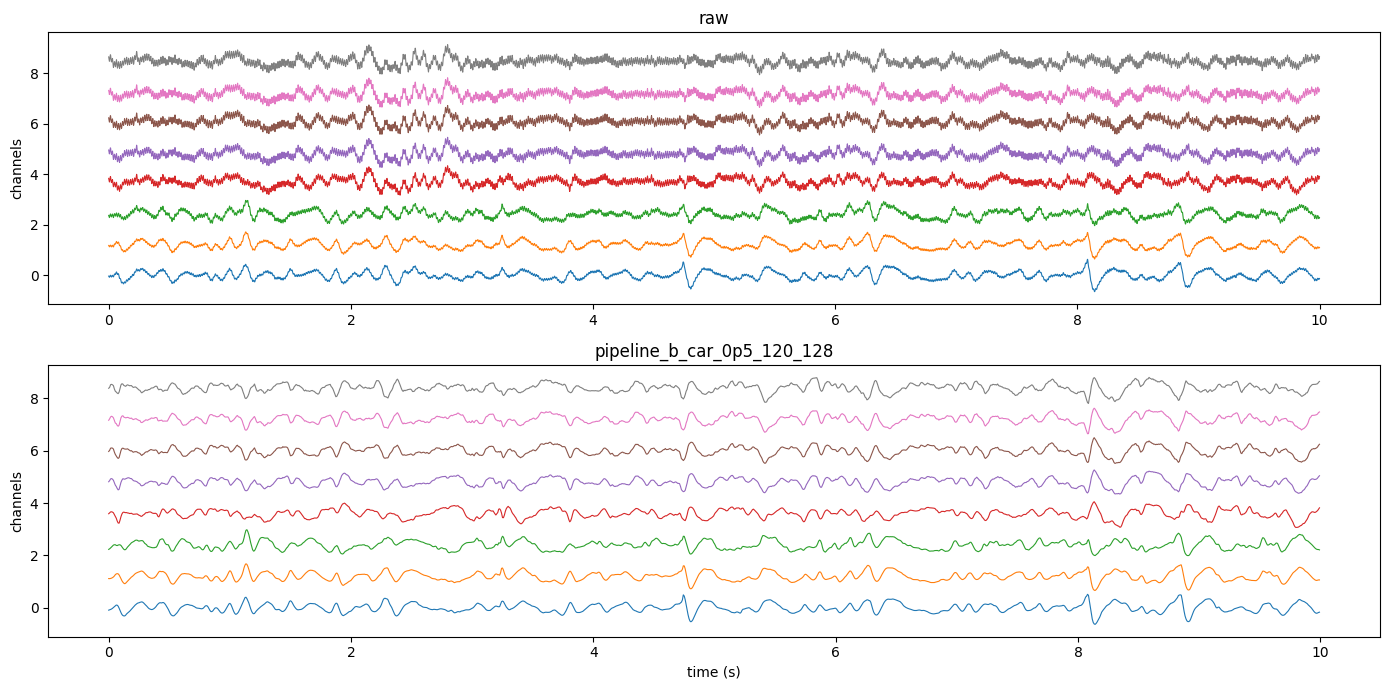


[pipeline_b_car_0p5_120_128] D:\HUP dataset\sub-HUP060\ses-presurgery\ieeg\sub-HUP060_ses-presurgery_task-ictal_acq-seeg_run-01_ieeg.edf
  seizure_duration=197.998s | windows=572/573 | ictal=395 | nonictal=177 | ignored_train=3

[pipeline_b_car_0p5_120_128] D:\HUP dataset\sub-HUP060\ses-presurgery\ieeg\sub-HUP060_ses-presurgery_task-ictal_acq-seeg_run-02_ieeg.edf
  seizure_duration=139.998s | windows=456/457 | ictal=279 | nonictal=177 | ignored_train=3

[pipeline_b_car_0p5_120_128] D:\HUP dataset\sub-HUP060\ses-presurgery\ieeg\sub-HUP060_ses-presurgery_task-ictal_acq-seeg_run-03_ieeg.edf
  seizure_duration=133.998s | windows=445/445 | ictal=267 | nonictal=178 | ignored_train=3

[pipeline_b_car_0p5_120_128] D:\HUP dataset\sub-HUP060\ses-presurgery\ieeg\sub-HUP060_ses-presurgery_task-interictal_acq-seeg_run-01_ieeg.edf
  seizure_duration=0.000s | windows=289/298 | ictal=0 | nonictal=289 | ignored_train=0

[pipeline_b_car_0p5_120_128] D:\HUP dataset\sub-HUP060\ses-presurgery\ieeg\sub-HUP

In [31]:
# ============================================================
# 6. MAIN
# ============================================================
if __name__ == "__main__":
    ensure_dir(OUT_ROOT)
    runs = discover_runs(BIDS_ROOT, subjects=SUBJECTS, sessions=SESSIONS)
    print(f"Found {len(runs)} run(s).")

    if PLOT_EXAMPLE_RUN is not None and PLOT_EXAMPLE_RUN.exists():
        example_channels = find_sidecar(PLOT_EXAMPLE_RUN, "_channels.tsv")
        example_json = find_sidecar(PLOT_EXAMPLE_RUN, "_ieeg.json")
        plot_before_after_preprocessing(
            edf_path=PLOT_EXAMPLE_RUN,
            channels_tsv=example_channels,
            json_path=example_json,
            pipeline=PIPELINE_B,
            start_sec=PLOT_START_SEC,
            duration_sec=PLOT_DURATION_SEC,
            n_channels=PLOT_CHANNELS,
        )

    qc_rows = []
    failed = []
    for run in runs:
        try:
            qc = preprocess_one_run(run, OUT_ROOT, PIPELINE_B)
            qc_rows.append(asdict(qc))
        except Exception as e:
            failed.append({
                "pipeline": PIPELINE_B["name"],
                "edf_path": str(run.edf_path),
                "subject": run.subject,
                "run": run.run,
                "error": repr(e),
                "traceback": traceback.format_exc(),
            })
            print(f"[FAILED] {PIPELINE_B['name']} | {run.edf_path}")
            print(traceback.format_exc())

    qc_df = pd.DataFrame(qc_rows)
    failed_df = pd.DataFrame(failed)

    if not qc_df.empty:
        qc_csv = OUT_ROOT / "qc_manifest_compare_ab_fixed.csv"
        qc_df.to_csv(qc_csv, index=False)
        print("\nSaved QC manifest:", qc_csv)
        print(qc_df.head())

        summary = (
            qc_df.groupby(["pipeline", "subject", "task"], dropna=False)[[
                "n_windows_kept", "ictal_window_count", "nonictal_window_count", "rejected_window_count",
                "ignored_ambiguous_train_windows", "seizure_duration_sec"
            ]]
            .sum()
            .reset_index()
        )
        print("\nSummary:")
        print(summary)

    if not failed_df.empty:
        failed_csv = OUT_ROOT / "failed_runs_compare_ab_fixed.csv"
        failed_df.to_csv(failed_csv, index=False)
        print("\nSaved failures:", failed_csv)